In [1]:
import os
import numpy
import pandas

import matplotlib.pyplot

### Part 1. Parse Open Targets data

In [3]:
DATA_DIR = "/home/kubicaj/open-targets-hackathon/targets-from-pathways/data/"

#### Associations - indirect (by data type)

In [4]:
associations_parquet_dir = DATA_DIR + "association_by_datasource_indirect/"
parquet_files = []
for f in os.listdir(associations_parquet_dir):
    if f.endswith(".parquet") or f.endswith(".snappy.parquet"):
        parquet_file = os.path.join(associations_parquet_dir, f)
        parquet_files.append(parquet_file)

associations = pandas.DataFrame()
for file in parquet_files:
    associations = pandas.concat([associations, pandas.read_parquet(file)])
associations.head()

,datatypeId,datasourceId,diseaseId,targetId,score,evidenceCount
0,literature,europepmc,EFO_0000318,ENSG00000000419,0.018238,1
1,literature,europepmc,EFO_0000318,ENSG00000000971,0.128679,3
2,literature,europepmc,EFO_0000318,ENSG00000001084,0.090936,4
3,literature,europepmc,EFO_0000318,ENSG00000001167,0.053194,2
4,literature,europepmc,EFO_0000318,ENSG00000001626,0.135362,23


#### Drug molecule (Drug/Clinical candidates)

In [5]:
drug_molecule = pandas.read_parquet(DATA_DIR + "drug_molecule/part-00000-871f412e-aec4-4d33-a50d-feee532ddcd2-c000.snappy.parquet")
print(f"number of drugs: {len(drug_molecule)}")
drug_molecule.head()

number of drugs: 18475


,id,canonicalSmiles,inchiKey,drugType,blackBoxWarning,name,yearOfFirstApproval,maximumClinicalTrialPhase,parentId,hasBeenWithdrawn,isApproved,tradeNames,synonyms,crossReferences,childChemblIds,linkedDiseases,linkedTargets,description
0,CHEMBL1000,O=C(O)COCCN1CCN(C(c2ccccc2)c2ccc(Cl)cc2)CC1,ZKLPARSLTMPFCP-UHFFFAOYSA-N,Small molecule,False,CETIRIZINE,1995.0,4.0,None,False,True,[],"[AC-170, Cetiderm, Cetirizina, Cetirizine]","[{'source': 'drugbank', 'ids': ['DB00341']}]","[CHEMBL1201113, CHEMBL1607273]","{'rows': ['EFO_0008521', 'HP_0000989', 'EFO_00...","{'rows': ['ENSG00000196639'], 'count': 1}",Small molecule drug with a maximum clinical tr...
1,CHEMBL100014,CCCC(=O)OCOC(=O)C(C)(C)C,GYKLFBYWXZYSOW-UHFFFAOYSA-N,Small molecule,False,AN-9,NaN,2.0,None,False,False,[],"[An-9, Butyric acid 2,2-dimethyl-propionyloxym...","[{'source': 'drugbank', 'ids': ['DB05103']}]",None,"{'rows': ['EFO_0003060', 'EFO_0000095', 'EFO_0...",None,Small molecule drug with a maximum clinical tr...
2,CHEMBL100109,CC(=O)N[C@H](Cc1ccccc1)C(=O)N1CCC[C@H]1C(=O)N[...,UCQIHCRMWNRFNP-QYZOEREBSA-N,Small molecule,False,CHEMBL100109,NaN,NaN,None,False,None,[],[],"[{'source': 'drugbank', 'ids': ['DB07658']}]",[CHEMBL3038261],None,None,Small molecule drug.
3,CHEMBL100116,CC(C)=CCN1CCC2(C)c3cc(O)ccc3CC1C2C,VOKSWYLNZZRQPF-UHFFFAOYSA-N,Small molecule,True,PENTAZOCINE,1967.0,4.0,None,False,True,[],"[Dl-pentazocine, NIH-7958, NSC-107430, Pentazo...",None,"[CHEMBL5483020, CHEMBL3989509, CHEMBL3989510]","{'rows': ['MONDO_0004985', 'HP_0012531', 'HP_0...","{'rows': ['ENSG00000147955'], 'count': 1}",Small molecule drug with a maximum clinical tr...
4,CHEMBL1002,CC(C)(C)NC[C@H](O)c1ccc(O)c(CO)c1,NDAUXUAQIAJITI-LBPRGKRZSA-N,Small molecule,True,LEVOSALBUTAMOL,1999.0,4.0,None,False,True,[],"[ASF-1096, Albuterol (r)-form, Levalbuterol, L...","[{'source': 'drugbank', 'ids': ['DB13139']}]","[CHEMBL3989693, CHEMBL1201061, CHEMBL3989589]","{'rows': ['MONDO_0004979', 'MONDO_0004979', 'E...","{'rows': ['ENSG00000169252'], 'count': 1}",Small molecule drug with a maximum clinical tr...


In [6]:
# identify drugs that have been withdrawn, map them to target genes (ENSG) and diseases (EFO);
# stores results in dictionaries: withdrawn_chemblID2ENSG and withdrawn_ENSG2EFO

withdrawn_chemblID2ENSG = {}
withdrawn_chemblIDEFO = {}

for index, row in drug_molecule.iterrows():
    # search only for withdrawn drugs
    if not row['hasBeenWithdrawn']:
        continue

    chemblID = row['id']

    # keep only drugs with linked targets
    if not row['linkedTargets']:
        print(f"{chemblID} has been withdrawn but has no linked targets")
        continue
    if row['linkedTargets']['count'] < 1:
        print(f"{chemblID} has been withdrawn but has no linked targets")
        continue
    targets = row['linkedTargets']['rows']  # format: {'rows': ['ENSG00000196639'], 'count': 1}

    # keep only drugs with linked diseases
    if not row['linkedDiseases']:
        print(f"{chemblID} has been withdrawn but has no linked diseases")
        continue
    diseases = row['linkedDiseases']['rows']  # format: {'rows': ['EFO_0008521', ...}
    if len(diseases) < 1:
        print(f"{chemblID} has been withdrawn but has no linked diseases")
        continue

    print(f"{chemblID} has been withdrawn for {diseases} associated with targets {targets}")

    # store withdrawn drug-target associations
    if chemblID not in withdrawn_chemblID2ENSG:
        withdrawn_chemblID2ENSG[chemblID] = []
    withdrawn_chemblID2ENSG[chemblID].extend(targets)

    # store withdrawn drug-disease associations
    if chemblID not in withdrawn_chemblIDEFO:
        withdrawn_chemblIDEFO[chemblID] = []
    withdrawn_chemblIDEFO[chemblID].extend(diseases)
    unique_diseases = set(diseases)
    withdrawn_chemblIDEFO[chemblID] = list(unique_diseases)

CHEMBL101 has been withdrawn for ['EFO_0005755' 'HP_0003326' 'HP_0002829'] associated with targets ['ENSG00000073756' 'ENSG00000095303']
CHEMBL1018 has been withdrawn but has no linked diseases
CHEMBL106258 has been withdrawn but has no linked targets
CHEMBL1077 has been withdrawn for ['HP_0200026' 'MONDO_0005129' 'EFO_0001365' 'MP_0001845' 'MONDO_0001330'
 'MP_0001845' 'MONDO_0005129' 'EFO_0005752' 'HP_0012531' 'EFO_1000906'
 'MONDO_0007935' 'EFO_0007141'] associated with targets ['ENSG00000073756' 'ENSG00000095303']
CHEMBL1089221 has been withdrawn for ['EFO_0005752' 'HP_0003326' 'HP_0002829'] associated with targets ['ENSG00000158125']
CHEMBL110691 has been withdrawn but has no linked diseases
CHEMBL1108 has been withdrawn for ['HP_0012531' 'HP_0002017' 'EFO_0005407' 'EFO_0004888'] associated with targets ['ENSG00000149295' 'ENSG00000151577' 'ENSG00000069696' 'ENSG00000102468']
CHEMBL111 has been withdrawn for ['EFO_0004329' 'EFO_0001073' 'HP_0001397' 'EFO_1001121' 'MONDO_0008300'
 

#### ChEMBL evidence

In [7]:
chembl_parquet_dir = DATA_DIR + "evidence_chembl/"
parquet_files = []
for f in os.listdir(chembl_parquet_dir):
    if f.endswith(".parquet") or f.endswith(".snappy.parquet"):
        parquet_file = os.path.join(chembl_parquet_dir, f)
        parquet_files.append(parquet_file)

chembl = pandas.DataFrame()
for file in parquet_files:
    chembl = pandas.concat([chembl, pandas.read_parquet(file)])
chembl.head()

,targetId,drugId,targetFromSourceId,diseaseFromSourceMappedId,clinicalPhase,clinicalStatus,cohortPhenotypes,datasourceId,datatypeId,diseaseFromSource,...,targetFromSource,urls,studyStopReasonCategories,qualityControls,diseaseId,id,evidenceDate,score,directionOnTrait,directionOnTarget
0,ENSG00000176884,CHEMBL742,Q05586,MONDO_0002050,1.0,Completed,None,chembl,known_drug,Depression,...,CHEMBL2094124,"[{'niceName': 'ClinicalTrials', 'url': 'https:...",None,[],MONDO_0002050,00009e083efc33e86e288352f5e9f619d233aee5,2017-12-01,0.1,protect,LoF
1,ENSG00000182256,CHEMBL1522,Q99928,EFO_0004698,3.0,Completed,None,chembl,known_drug,Primary Insomnia,...,CHEMBL2093872,"[{'niceName': 'ClinicalTrials', 'url': 'https:...",None,[],EFO_0004698,0000c95d2a177e3e113b95b038229b26f8321be0,2001-02-01,0.7,protect,GoF
2,ENSG00000137745,CHEMBL1433,P45452,EFO_0003818,2.0,Recruiting,None,chembl,known_drug,Pulmonary Disease Due to Mycobacteria (Diagnosis),...,CHEMBL280,"[{'niceName': 'ClinicalTrials', 'url': 'https:...",None,[],EFO_0003818,00029329f674d4523c5125001d0b8b2a40cf26db,2020-03-02,0.2,protect,LoF
3,ENSG00000119013,CHEMBL1703,O43676,MONDO_0005148,4.0,None,None,chembl,known_drug,type 2 diabetes mellitus,...,CHEMBL2363065,"[{'niceName': 'DailyMed', 'url': 'https://dail...",None,[],MONDO_0005148,000323684a05ef1c120cca8a05f9d8e9e25ebba9,None,1.0,protect,LoF
4,ENSG00000168539,CHEMBL2146146,P11229,MONDO_0005180,4.0,None,None,chembl,known_drug,parkinsonism,...,CHEMBL216,"[{'niceName': 'DailyMed', 'url': 'https://dail...",None,[],MONDO_0005180,0003513df4828fafb56ca0702fee8df36c253de7,None,1.0,protect,LoF


#### Target (gene-to-ENSG mapping)

In [8]:
target_parquet_dir = DATA_DIR + "target/"
parquet_files = []
for f in os.listdir(target_parquet_dir):
    if f.endswith(".parquet") or f.endswith(".snappy.parquet"):
        parquet_file = os.path.join(target_parquet_dir, f)
        parquet_files.append(parquet_file)

target = pandas.DataFrame()
for file in parquet_files:
    target = pandas.concat([target, pandas.read_parquet(file)])
target.head()

,id,approvedSymbol,biotype,transcriptIds,canonicalTranscript,canonicalExons,genomicLocation,alternativeGenes,approvedName,go,...,constraint,tep,proteinIds,dbXrefs,chemicalProbes,homologues,tractability,safetyLiabilities,pathways,tss
0,ENSG00000000457,SCYL3,protein_coding,"[ENST00000423670, ENST00000367770, ENST0000036...","{'id': 'ENST00000367771', 'chromosome': '1', '...","[169854270, 169854964, 169868928, 169869039, 1...","{'chromosome': '1', 'start': 169846981, 'end':...",None,SCY1 like pseudokinase 3,"[{'id': 'GO:0042802', 'source': 'GO_REF:000010...",...,"[{'constraintType': 'syn', 'score': 1.07690000...",None,"[{'id': 'Q8IZE3', 'source': 'uniprot_swissprot...","[{'id': '19285', 'source': 'HGNC'}, {'id': 'IP...",None,"[{'speciesId': '9606', 'speciesName': 'Human',...","[{'modality': 'SM', 'id': 'Approved Drug', 'va...",None,None,169893896.0
1,ENSG00000001167,NFYA,protein_coding,"[ENST00000914458, ENST00000914462, ENST0000091...","{'id': 'ENST00000341376', 'chromosome': '6', '...","[41094396, 41094497, 41091528, 41091694, 41084...","{'chromosome': '6', 'start': 41072946, 'end': ...",None,nuclear transcription factor Y subunit alpha,"[{'id': 'GO:0000785', 'source': 'GO_REF:000011...",...,"[{'constraintType': 'syn', 'score': 0.46832001...",None,"[{'id': 'P23511', 'source': 'uniprot_swissprot...","[{'id': '7804', 'source': 'HGNC'}, {'id': '4AW...",None,"[{'speciesId': '9598', 'speciesName': 'Chimpan...","[{'modality': 'SM', 'id': 'Approved Drug', 'va...",None,"[{'pathwayId': 'R-HSA-9614657', 'pathway': 'FO...",41072974.0
2,ENSG00000001460,STPG1,protein_coding,"[ENST00000483528, ENST00000468303, ENST0000043...","{'id': 'ENST00000337248', 'chromosome': '1', '...","[24413674, 24413782, 24369674, 24369839, 24360...","{'chromosome': '1', 'start': 24355886, 'end': ...",None,sperm tail PG-rich repeat containing 1,"[{'id': 'GO:1902110', 'source': 'GO_REF:000003...",...,"[{'constraintType': 'syn', 'score': 0.54615998...",None,"[{'id': 'Q5TH74', 'source': 'uniprot_swissprot...","[{'id': '28070', 'source': 'HGNC'}, {'id': 'IP...",None,"[{'speciesId': '9606', 'speciesName': 'Human',...","[{'modality': 'SM', 'id': 'Approved Drug', 'va...",None,None,24413782.0
3,ENSG00000001629,ANKIB1,protein_coding,"[ENST00000439883, ENST00000422095, ENST0000092...","{'id': 'ENST00000265742', 'chromosome': '7', '...","[92307359, 92307656, 92294889, 92295166, 92319...","{'chromosome': '7', 'start': 92245973, 'end': ...",None,ankyrin repeat and IBR domain containing 1,"[{'id': 'GO:0008270', 'source': 'GO_REF:000000...",...,"[{'constraintType': 'syn', 'score': 1.35239994...",None,"[{'id': 'Q9P2G1', 'source': 'uniprot_swissprot...","[{'id': '22215', 'source': 'HGNC'}, {'id': 'IP...",None,"[{'speciesId': '9606', 'speciesName': 'Human',...","[{'modality': 'SM', 'id': 'Approved Drug', 'va...",None,None,92245974.0
4,ENSG00000003096,KLHL13,protein_coding,"[ENST00000881391, ENST00000881390, ENST0000037...","{'id': 'ENST00000540167', 'chromosome': 'X', '...","[117920238, 117920370, 117919521, 117919717, 1...","{'chromosome': 'X', 'start': 117897794, 'end':...",None,kelch like family member 13,"[{'id': 'GO:0005829', 'source': 'Reactome:R-HS...",...,None,None,"[{'id': 'Q9P2N7', 'source': 'uniprot_swissprot...","[{'id': '22931', 'source': 'HGNC'}, {'id': 'R-...",None,"[{'speciesId': '9606', 'speciesName': 'Human',...","[{'modality': 'SM', 'id': 'Approved Drug', 'va...",None,"[{'pathwayId': 'R-HSA-983168', 'pathway': 'Ant...",118116810.0


In [9]:
# map ENSG to gene names and vice versa
ENSG2gene_name = {}
gene_name2ENSG = {}
for index, row in target.iterrows():
    ENSG = row['id']
    gene = row['approvedSymbol']

    # some entries are incomplete
    if ENSG == gene:
        continue
    if ENSG in ENSG2gene_name:
        assert ENSG2gene_name[ENSG] == gene
    if gene in gene_name2ENSG:
        print(f"{gene} already mapped to {gene_name2ENSG[gene]}, skipping it")
        continue

    ENSG2gene_name[ENSG] = gene
    gene_name2ENSG[gene] = ENSG

assert len(ENSG2gene_name) == len(gene_name2ENSG)

Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipping it
Y_RNA already mapped to ENSG00000199263, skipp

### Part 2. Find alternative treatments for new candidates

In [31]:
# define the not-working target and disease of interest
GENE = "HTR2A"
DISEASE = "MONOD_0002009"

In [32]:
# read the scores for the not-working target and disease of interest
gene2score = {}
gene2pathways = {}
scores = pandas.read_csv(f"{GENE}-{DISEASE}/scores.tsv", sep="\t")

for index, row in scores.iterrows():
    if row["GENE"] not in gene_name2ENSG:
        print(f"{row['GENE']} not found in gene_name2ENSG, skipping it")
        continue
    gene2score[row['GENE']] = row['SCORE']
    gene2pathways[row['GENE']] = row['PATHWAYS']

print(f"Found {len(gene2score)} new candidate targets")

results_sorted = sorted(gene2score.keys(), key=lambda item: gene2score[item], reverse=True)

FileNotFoundError: [Errno 2] No such file or directory: 'HTR2A-MONOD_0002009/scores.tsv'

In [ ]:
# check if top 20 highest-scoring genes have other targets for the disease
top_20_genes = results_sorted[:20]
for gene in top_20_genes:
    if gene not in gene_name2ENSG:
        print(f"{gene} ({ENSG}) not found in gene_name2ENSG")
        continue

    ENSG = gene_name2ENSG[gene]

    chembl_subset = chembl[
        (chembl['targetId'] == ENSG) &
        (chembl['diseaseFromSourceMappedId'] == DISEASE)
    ]
    drug_ids = chembl_subset['drugId'].to_list()
    notWithdrawnCount = 0
    for chemblID in drug_ids:
        if chemblID not in withdrawn_chemblID2ENSG:
            notWithdrawnCount += 1
    if notWithdrawnCount > 0:
        print(f"Gene {gene} ({ENSG}) has {len(drug_ids)} drugs associated with {DISEASE}, {notWithdrawnCount} NOT withdrawn")
    else:
        print(f"Gene {gene} ({ENSG}) has {len(drug_ids)} drugs associated with {DISEASE}")

Gene PIK3R1 (ENSG00000145675) has 0 drugs associated with EFO_0005755
Gene PSMC6 (ENSG00000100519) has 0 drugs associated with EFO_0005755
Gene PPP2CA (ENSG00000113575) has 0 drugs associated with EFO_0005755
Gene PPP2R1A (ENSG00000105568) has 0 drugs associated with EFO_0005755
Gene PPP2R1B (ENSG00000137713) has 0 drugs associated with EFO_0005755
Gene SEM1 (ENSG00000127922) has 0 drugs associated with EFO_0005755
Gene PPP2CB (ENSG00000104695) has 0 drugs associated with EFO_0005755
Gene PSMB6 (ENSG00000142507) has 0 drugs associated with EFO_0005755
Gene PSMB2 (ENSG00000126067) has 0 drugs associated with EFO_0005755
Gene PSMB5 (ENSG00000100804) has 0 drugs associated with EFO_0005755
Gene PSMA6 (ENSG00000100902) has 0 drugs associated with EFO_0005755
Gene PSMB3 (ENSG00000277791) has 0 drugs associated with EFO_0005755
Gene PSMB1 (ENSG00000008018) has 0 drugs associated with EFO_0005755
Gene PSMB4 (ENSG00000159377) has 0 drugs associated with EFO_0005755
Gene PSMA4 (ENSG00000041357)

### Part 3. Find association and evidence scores for new candidates

In [ ]:
ENSG2association = {}
ENSG2evidence = {}

disease_associations = associations[associations['diseaseId'] == DISEASE]

for index, row in disease_associations.iterrows():
    ENSG = row['targetId']

    ENSG2association[ENSG] = row["score"]
    ENSG2evidence[ENSG] = row["evidenceCount"]

assert len(ENSG2association) == len(ENSG2evidence)

In [ ]:
scores_sorted = []
associations_sorted = []
evidence_sorted = []

for gene in gene2score:
    if gene not in gene_name2ENSG:
        print(f"{gene} not found in gene_name2ENSG, skipping it")
        continue
    ENSG = gene_name2ENSG[gene]

    if ENSG not in ENSG2association:
        print(f"{ENSG} has no association with {DISEASE}")
        continue
    
    scores_sorted.append(gene2score[gene])
    associations_sorted.append(ENSG2association[ENSG])
    evidence_sorted.append(ENSG2evidence[ENSG])

assert len(associations_sorted) == len(evidence_sorted) == len(scores_sorted)

print(f"{len(scores_sorted)} genes have associations with {DISEASE}")

ENSG00000104695 has no association with EFO_0005755
ENSG00000008018 has no association with EFO_0005755
ENSG00000161057 has no association with EFO_0005755
ENSG00000130706 has no association with EFO_0005755
ENSG00000099341 has no association with EFO_0005755
ENSG00000185627 has no association with EFO_0005755
ENSG00000163636 has no association with EFO_0005755
ENSG00000108671 has no association with EFO_0005755
ENSG00000168710 has no association with EFO_0005755
ENSG00000165059 has no association with EFO_0005755
ENSG00000186298 has no association with EFO_0005755
ENSG00000159445 has no association with EFO_0005755
ENSG00000075188 has no association with EFO_0005755
ENSG00000069248 has no association with EFO_0005755
ENSG00000167261 has no association with EFO_0005755
ENSG00000280969 has no association with EFO_0005755
ENSG00000110700 has no association with EFO_0005755
ENSG00000101849 has no association with EFO_0005755
ENSG00000134419 has no association with EFO_0005755
ENSG00000233

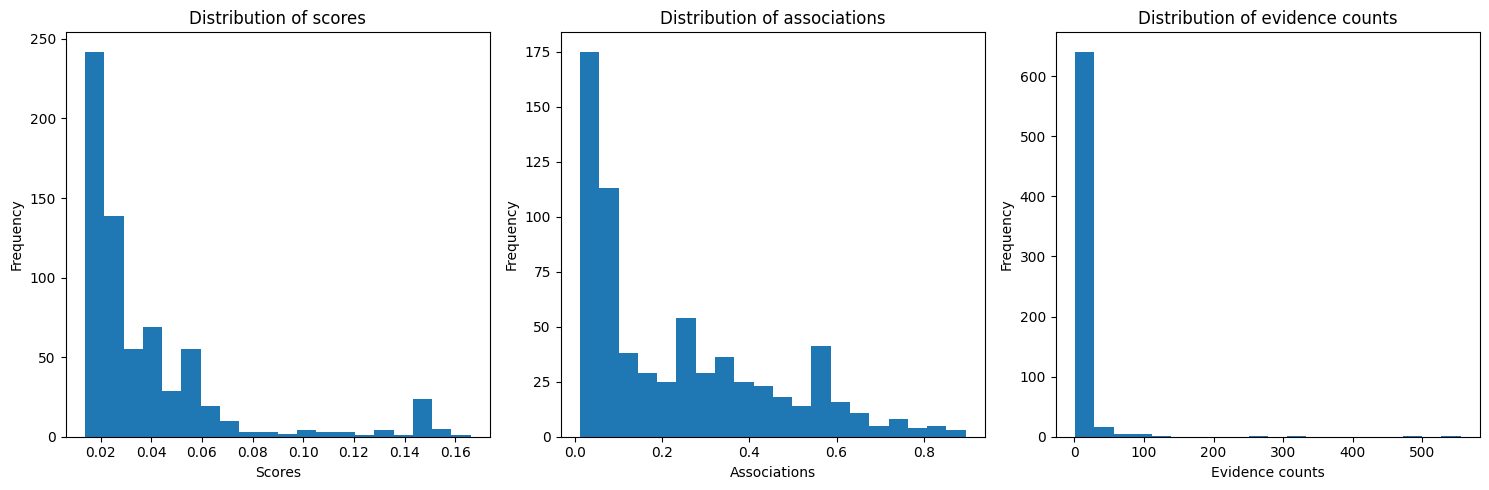

In [ ]:
# 3 histograms of scores_sorted, associations_sorted and evidence_sorted
matplotlib.pyplot.figure(figsize=(15, 5))

matplotlib.pyplot.subplot(1, 3, 1)
matplotlib.pyplot.hist(scores_sorted, bins=20)
matplotlib.pyplot.xlabel("Scores")
matplotlib.pyplot.ylabel("Frequency")
matplotlib.pyplot.title("Distribution of scores")

matplotlib.pyplot.subplot(1, 3, 2)
matplotlib.pyplot.hist(associations_sorted, bins=20)
matplotlib.pyplot.xlabel("Associations")
matplotlib.pyplot.ylabel("Frequency")
matplotlib.pyplot.title("Distribution of associations")

matplotlib.pyplot.subplot(1, 3, 3)
matplotlib.pyplot.hist(evidence_sorted, bins=20)
matplotlib.pyplot.xlabel("Evidence counts")
matplotlib.pyplot.ylabel("Frequency")
matplotlib.pyplot.title("Distribution of evidence counts")

matplotlib.pyplot.tight_layout()
matplotlib.pyplot.savefig(f"{GENE}-{DISEASE}/scores-associations-evidence-hist.png")

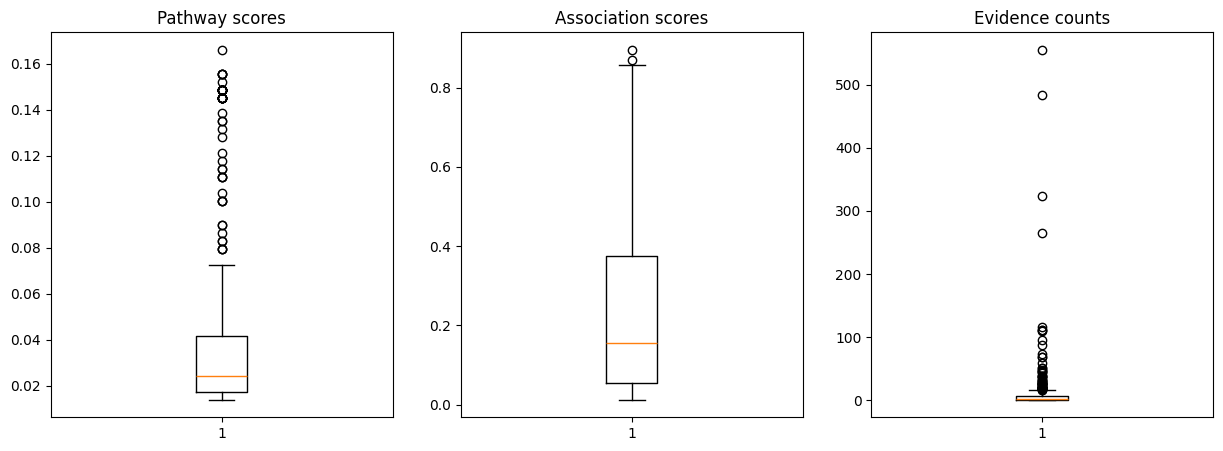

In [ ]:
# 3 boxplots of scores_sorted, associations_sorted and evidence_sorted
matplotlib.pyplot.figure(figsize=(15, 5))
matplotlib.pyplot.subplot(1, 3, 1)
matplotlib.pyplot.boxplot(scores_sorted)
matplotlib.pyplot.title("Pathway scores")
matplotlib.pyplot.subplot(1, 3, 2)
matplotlib.pyplot.boxplot(associations_sorted)
matplotlib.pyplot.title("Association scores")
matplotlib.pyplot.subplot(1, 3, 3)
matplotlib.pyplot.boxplot(evidence_sorted)
matplotlib.pyplot.title("Evidence counts")

matplotlib.pyplot.savefig(f"{GENE}-{DISEASE}/scores-associations-evidence-box.png")

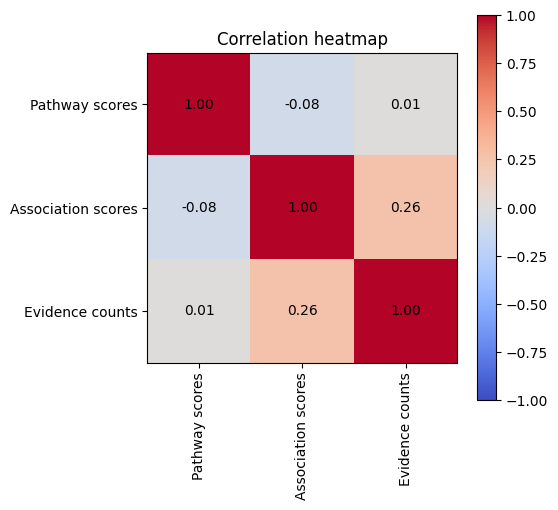

In [ ]:
# correlation heatmap: scores_sorted, associations_sorted and evidence_sorted
correlation_matrix = numpy.corrcoef([scores_sorted, associations_sorted, evidence_sorted])

matplotlib.pyplot.figure(figsize=(5, 5))
matplotlib.pyplot.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)

# add correlation values to heatmap
for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix)):
        matplotlib.pyplot.text(j, i, f"{correlation_matrix[i, j]:.2f}", ha='center', va='center', color='black')

matplotlib.pyplot.title("Correlation heatmap")
matplotlib.pyplot.xticks([0, 1, 2], ["Pathway scores", "Association scores", "Evidence counts"], rotation=90)
matplotlib.pyplot.yticks([0, 1, 2], ["Pathway scores", "Association scores", "Evidence counts"])
matplotlib.pyplot.colorbar()
matplotlib.pyplot.savefig(f"{GENE}-{DISEASE}/correlation_heatmap.png")

### Part 4. Find common pathways for new candidates

In [ ]:
# find common pathways for new candidates
pathway_sets = [set(pathways.split(',')) for pathways in gene2pathways.values()]

common_pathways = set.intersection(*pathway_sets)

print("Pathways common to all new candidates:", common_pathways)

Pathways common to all new candidates: {'R-HSA-1430728'}
